# 03b-02 - What a Feature Is

The second box of the lecture's pipeline is the tie points, and it is where the photographs stop being pictures and become measurements. The software went through every photograph on its own and found a few thousand places in each that it could hope to find again in the others, each with a position, a size, a direction, and a list of 128 numbers that describes the patch around it. It did this at 2000 pixels on the long side, which is exactly the size of the copies in the kit, so nothing the software saw is missing here. Matching those places between photographs is the next notebook; this one is about what a place worth matching is.

We start by hand. We find corners in one photograph with the Harris response, a thirty-year-old recipe of a few lines, and look at where they sit. We count them inside the field against outside it, because the mown lawn is the question of this flight, and the count needs the field's outline projected into the photograph. We build a difference-of-Gaussians stack on one crop and see why a feature must carry its size. Then we open the software's features of the same photograph, compare their count and their places with ours, and take one descriptor apart to see what the 128 numbers are and how far apart two of them can be.

This notebook reads the flight named in `data/flight.json`, and was written on the pre-flight of 17 September 2026. Before you run anything, choose *File*, then *Save As*, and give the copy a name with `-mywork` in it, so that next week's pull never collides with your work.

In [1]:
import json
import math

import numpy as np
import geopandas as gpd
import rasterio
from PIL import Image
from scipy import ndimage as ndi
from shapely.geometry import Point, Polygon, box
import matplotlib.pyplot as plt
from matplotlib.path import Path as MplPath
import seaborn as sns

plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 72

flight = json.load(open("data/flight.json"))
choices = flight["p03b"]
reference = json.load(open("data/ground_truth.json"))["p03b"]
print(f"this notebook reads the flight {flight['label']} of {flight['date']}: {flight['aircraft']} at {flight['altitude_agl_m']} m, {flight['n_photos']} photographs, processed with {flight['processing']['software']}")

this notebook reads the flight flight-2026-09-23 of 2026-09-23: DJI Mini 3 at 79.3 m, 85 photographs, processed with OpenDroneMap


## One photograph, and what a corner is

A feature is a place that can be found again. A stretch of lawn cannot, because every patch of lawn looks like every other; the corner of a roof can, because there is exactly one place where those two edges meet. The oldest way to find such places is Harris's. Take the picture's gradient, average the products of its two components over a small window, and look at the two eigenvalues of that little matrix, the structure tensor. Where both are small nothing changes and the patch is flat; where one is large the patch is an edge, which can slide along itself; where both are large the patch changes in two directions at once, and that is a corner. The response below is a shortcut for "both large" that never computes an eigenvalue, the determinant minus a small multiple of the trace squared. Here it is on the photograph, in grey, with the strongest corners kept after each has beaten its neighbours:

the copy is 2000 by 1500 pixels; 5000 corners kept, with responses from 211 to 704166


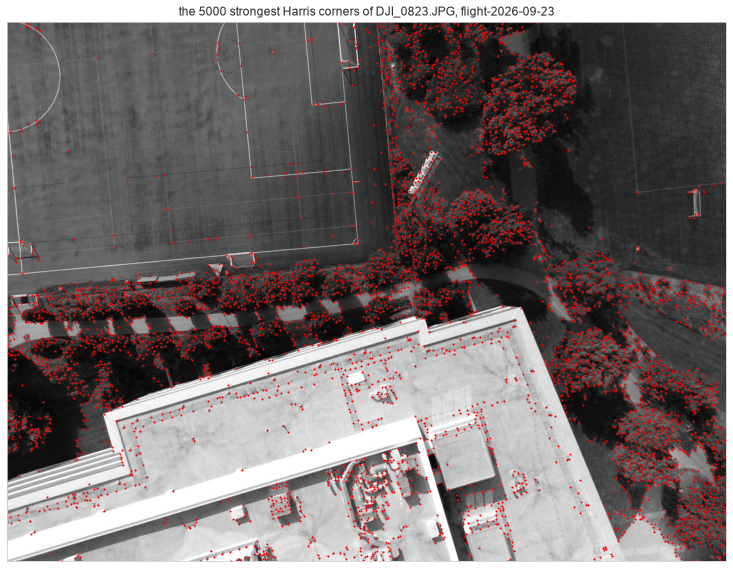

In [2]:
img = Image.open("data/photo_a.jpg")
gray = np.asarray(img.convert("L"), dtype=np.float32)
sample_h, sample_w = gray.shape                                         # the copy's size, always read from the image itself

def harris(gray, sigma_grad=1.0, sigma_win=2.0, k=0.05, nms=7, n=5000):
    '''Harris corners: smoothed gradients, the structure tensor averaged over a window, the response det minus k times trace squared, one peak per window, the n strongest. Returns rows, columns and responses.'''
    g = np.asarray(gray, dtype=np.float32)
    ix = ndi.gaussian_filter(g, sigma_grad, order=(0, 1))                # the derivative across the picture, smoothed a little
    iy = ndi.gaussian_filter(g, sigma_grad, order=(1, 0))                # and down it
    sxx = ndi.gaussian_filter(ix * ix, sigma_win)                         # the structure tensor, each product averaged over a Gaussian window
    syy = ndi.gaussian_filter(iy * iy, sigma_win)
    sxy = ndi.gaussian_filter(ix * iy, sigma_win)
    response = (sxx * syy - sxy * sxy) - k * (sxx + syy) ** 2             # large only where both eigenvalues are large
    peaks = (response == ndi.maximum_filter(response, size=nms)) & (response > 0)   # a corner must beat every neighbour in its window
    rows, cols = np.nonzero(peaks)
    order = np.argsort(-response[rows, cols])[:n]
    return rows[order], cols[order], response[rows[order], cols[order]]

rows, cols, response = harris(gray)
print(f"the copy is {sample_w} by {sample_h} pixels; {len(rows)} corners kept, with responses from {response.min():.0f} to {response.max():.0f}")

fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(gray, cmap="gray")
ax.scatter(cols, rows, s=4, color="red", linewidths=0)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title(f"the {len(rows)} strongest Harris corners of {choices['photos']['a']['name']}, {flight['label']}", fontsize=12)
fig.tight_layout()

The responses run over several orders of magnitude, and the picture shows where. Look at what the dots sit on, the edges and vents of the roof, the kerbs and joints of the paths, the lines painted on the pitch, the texture of the crowns and the shrubs. Then look at where they are sparse or absent, and do not decide about the lawn yet, because the eye is a poor counter of dots on a dark ground; the next section counts.

To look closely we cut a crop around one thing every flight of this site sees, the corner of the flat roof inside the pinned window of P03. Finding that corner in the photograph needs to know where the camera was and how a point on the ground becomes a pixel, which the software solved and 03b-04 explains. Here we borrow its answer as a tool, the pose of this photograph, the camera it calibrated, and the collinearity equations that carry a map coordinate at a known height into the picture. The corner itself comes from the building outline in the site file:

the roof's corner is 7.6 m from the window's centre and lands at pixel (1352, 758); the crop of 300 by 300 pixels around it holds 149 of the corners


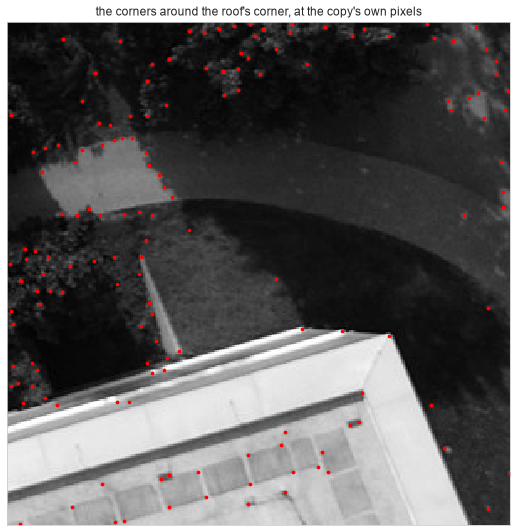

In [3]:
block = np.load("data/block.npz")
camera = json.loads(str(block["camera"]))
names = [str(n) for n in block["names"]]
shot = names.index(choices["photos"]["a"]["name"])
pose = (block["rotation_map"][shot], block["translation_map"][shot])      # the map frame, the products' system minus an offset
offset = np.asarray(block["offset"], dtype=float)

def rodrigues(rv):
    '''The rotation matrix of an axis angle vector.'''
    rv = np.asarray(rv, dtype=float); theta = float(np.linalg.norm(rv))
    if theta < 1e-12:
        return np.eye(3)
    k = rv / theta; K = np.array([[0.0, -k[2], k[1]], [k[2], 0.0, -k[0]], [-k[1], k[0], 0.0]])
    return np.eye(3) + math.sin(theta) * K + (1.0 - math.cos(theta)) * K @ K

def project_brown(X, rotation, translation, camera, width, height):
    '''The collinearity equations in the software's form: world to camera, the perspective division, the Brown distortion, then pixels of an image of the given size.'''
    X = np.atleast_2d(np.asarray(X, dtype=float))
    p = X @ rodrigues(rotation).T + np.asarray(translation, dtype=float)
    x, y = p[:, 0] / p[:, 2], p[:, 1] / p[:, 2]
    r2 = x * x + y * y
    radial = 1.0 + camera["k1"] * r2 + camera["k2"] * r2 ** 2 + camera["k3"] * r2 ** 3
    xd = x * radial + 2.0 * camera["p1"] * x * y + camera["p2"] * (r2 + 2.0 * x * x)
    yd = y * radial + 2.0 * camera["p2"] * x * y + camera["p1"] * (r2 + 2.0 * y * y)
    size = max(width, height)
    return (camera["focal_x"] * xd + camera["c_x"]) * size + width / 2.0 - 0.5, (camera["focal_y"] * yd + camera["c_y"]) * size + height / 2.0 - 0.5, p[:, 2]

with rasterio.open("data/dtm_window.tif") as src:
    z_ground = float(np.nanmedian(src.read(1, masked=True).filled(np.nan)))   # the terrain's height under the window, in the products' frame

def to_pixels(xy, z=z_ground):
    '''Map coordinates at one height into pixels of the copy we draw on.'''
    xy = np.asarray(xy, dtype=float)
    X = np.column_stack([xy[:, 0] - offset[0], xy[:, 1] - offset[1], np.full(len(xy), z)])
    u, v, _ = project_brown(X, *pose, camera, sample_w, sample_h)
    return u, v

window = box(*choices["window"]["bounds"])
buildings = gpd.read_file("data/site.gpkg", layer="buildings_site").to_crs(choices["crs"])
largest = lambda g: max(g.geoms, key=lambda p: p.area) if hasattr(g, "geoms") else g   # noqa: E731
building = largest(buildings[buildings.intersects(window)].geometry.iloc[0])            # the flat roof whose corner the window holds
centre = Point(*choices["window"]["centre"])
corner = min((Point(x, y) for x, y in np.array(building.exterior.coords)[:-1] if window.contains(Point(x, y))), key=centre.distance)
corner_u, corner_v = (float(c[0]) for c in to_pixels([[corner.x, corner.y]]))
half = 150
c0 = int(np.clip(round(corner_u) - half, 0, sample_w - 2 * half)); r0 = int(np.clip(round(corner_v) - half, 0, sample_h - 2 * half))
crop = gray[r0:r0 + 2 * half, c0:c0 + 2 * half]
in_crop = (cols >= c0) & (cols < c0 + 2 * half) & (rows >= r0) & (rows < r0 + 2 * half)
print(f"the roof's corner is {corner.distance(centre):.1f} m from the window's centre and lands at pixel ({corner_u:.0f}, {corner_v:.0f}); the crop of {2 * half} by {2 * half} pixels around it holds {int(in_crop.sum())} of the corners")

fig, ax = plt.subplots(figsize=(7.5, 7.5))
ax.imshow(crop, cmap="gray", interpolation="nearest")
ax.scatter(cols[in_crop] - c0, rows[in_crop] - r0, s=14, color="red", linewidths=0)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("the corners around the roof's corner, at the copy's own pixels", fontsize=12)
fig.tight_layout()

The corner of the outline lands near the roof's corner in the picture but not on it, and the gap has two causes. The outline was drawn at the ground's height while the roof stands above it, so the roof's image is pushed outward from the picture's centre, which is the relief displacement of 03-03 in miniature and the reason 03b-07 needs a surface model; and the outline itself is a volunteer's tracing of an aerial picture, good to a few metres. Neither matters for a crop. Now read it. The dots sit at the ends of the parapet, on the vents and the joints of the roof, along the kerb where the path meets the grass, and inside the crowns wherever a lit leaf meets a dark gap; the long straight edges of the roof carry far fewer dots than their length would suggest, because an edge is not a corner, and the response was built to say so. That is the whole idea, and everything the software does at this stage is a refinement of it.

## The field against the rest

The lawn is the question of this flight, because a mown lawn is the thing the lecture said a matcher finds nothing in. To count corners inside the field against outside it we need the field's outline inside the photograph, so we project it with the same tool, at the terrain's height, and clip it to the frame for its share of the picture; a fair count is per megapixel, since the field covers only part of the frame:

the field covers 15.9% of the frame   reference 15.9%
of the 5000 corners 518 are inside the field and 4482 outside   reference 518 and 4482
per megapixel that is 1085 inside and 1777 outside   reference 1085 and 1777


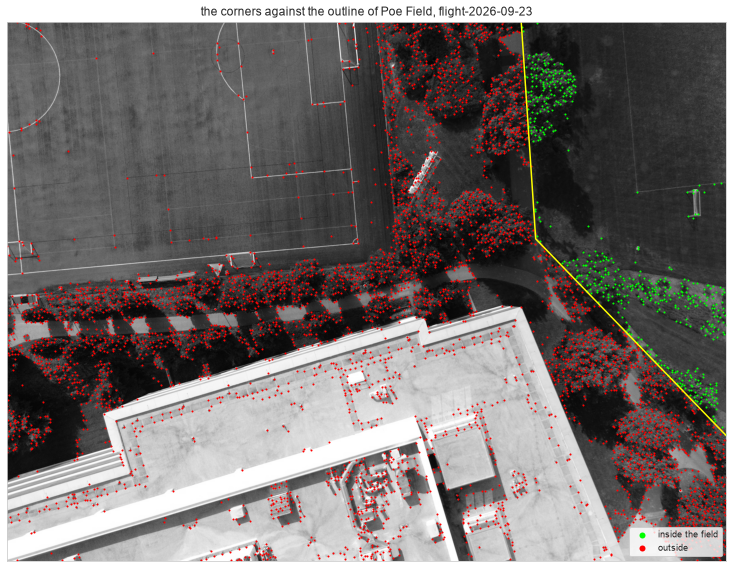

In [4]:
site = gpd.read_file("data/site.gpkg", layer="site").to_crs(choices["crs"])
field = site.geometry.iloc[0]
field_u, field_v = to_pixels(np.array(field.exterior.coords))
field_path = MplPath(np.column_stack([field_u, field_v]))                                         # the outline as a path that can test points
field_share = Polygon(np.column_stack([field_u, field_v])).intersection(box(0, 0, sample_w, sample_h)).area / (sample_w * sample_h)
megapixels_inside = field_share * sample_w * sample_h / 1e6
megapixels_outside = (1 - field_share) * sample_w * sample_h / 1e6
inside = field_path.contains_points(np.column_stack([cols, rows]))
h = reference["features"]["harris_top5000"]
print(f"the field covers {field_share:.1%} of the frame   reference {reference['features']['field_share_of_frame']:.1%}")
print(f"of the {len(rows)} corners {inside.sum()} are inside the field and {(~inside).sum()} outside   reference {h['inside_field']} and {h['outside_field']}")
print(f"per megapixel that is {inside.sum() / megapixels_inside:.0f} inside and {(~inside).sum() / megapixels_outside:.0f} outside   reference {h['per_megapixel_inside']:.0f} and {h['per_megapixel_outside']:.0f}")

fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(gray, cmap="gray")
ax.plot(field_u, field_v, color="yellow", linewidth=1.5)
ax.scatter(cols[inside], rows[inside], s=4, color="lime", linewidths=0, label="inside the field")
ax.scatter(cols[~inside], rows[~inside], s=4, color="red", linewidths=0, label="outside")
ax.set_xlim(0, sample_w); ax.set_ylim(sample_h, 0); ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc="lower right", fontsize=9, markerscale=3)
ax.set_title(f"the corners against the outline of Poe Field, {flight['label']}", fontsize=12)
fig.tight_layout()

Read the two numbers per megapixel against each other. The strongest few thousand corners are the detector's whole harvest, and if the field's density is close to the rest's, the lawn is not empty of corners at all; a mown lawn has stripes, wear, clover and the shadows of every unevenness, and at this pixel size those are texture. What the number does not say is how strong those corners are or whether any of them can be found again in the next photograph. The your turn at the end repeats the count for the strongest thousand only, and that is where the lawn shows its hand.

## Scale, or why a feature carries its size

A corner has a position but no size. Look at the crop again. The parapet's corner is a corner at any magnification, but a vent on the roof, a shrub, the lobe of a crown are things of a particular size, and a detector that hopes to find the same thing again from another altitude must know how big it was. The standard trick is the difference of Gaussians. Blur the picture a little and a little more and subtract; the difference responds to blobs of about the blur's size and to nothing else. Stack such differences over growing blurs, halve the picture for the next octave and go on, and a blob is a point that beats its twenty six neighbours in position and in scale at once. A test on the second derivatives throws out the responses that curve in one direction only, which are edges again. Here is the stack on the crop, each blob drawn as a circle of its own size:

84 blobs on the crop, with sigmas from 1.9 to 7.6 px; per octave 75, 8, 1


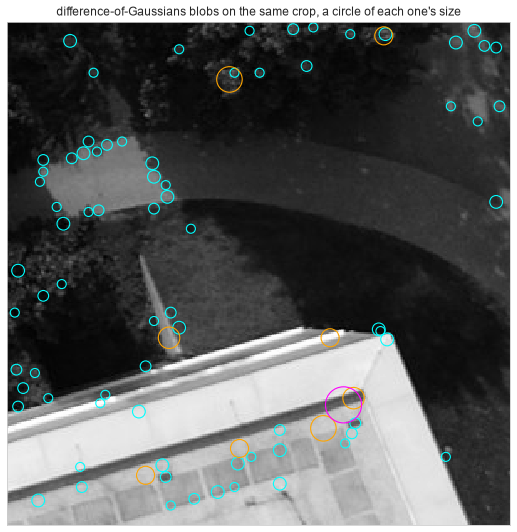

In [5]:
def dog_blobs(gray, sigma0=1.6, per_octave=4, octaves=3, threshold=2.5, edge_ratio=10.0):
    '''Blobs by the difference of Gaussians: per octave a stack of blurs, their differences, the extrema over three by three by three, an edge test on the second derivatives, then the picture halved for the next octave. Returns column, row, sigma and strength per blob.'''
    blobs = []
    layer = np.asarray(gray, dtype=np.float32)
    for octave in range(octaves):
        sigmas = [sigma0 * 2 ** (i / per_octave) for i in range(per_octave + 2)]
        blurred = np.stack([ndi.gaussian_filter(layer, s) for s in sigmas])
        dog = blurred[1:] - blurred[:-1]                                                   # one difference per pair of neighbouring blurs
        strength = np.abs(dog)                                                             # dark blobs and bright blobs alike
        peaks = (strength == ndi.maximum_filter(strength, size=3)) & (strength > threshold)
        peaks[0] = peaks[-1] = False                                                       # the outer layers have no neighbour on one side
        for k, r, c in zip(*np.nonzero(peaks)):
            if not (1 <= r < dog.shape[1] - 1 and 1 <= c < dog.shape[2] - 1):
                continue
            d = dog[k]
            dxx = d[r, c + 1] + d[r, c - 1] - 2 * d[r, c]; dyy = d[r + 1, c] + d[r - 1, c] - 2 * d[r, c]
            dxy = (d[r + 1, c + 1] - d[r + 1, c - 1] - d[r - 1, c + 1] + d[r - 1, c - 1]) / 4
            det, trace = dxx * dyy - dxy * dxy, dxx + dyy
            if det <= 0 or trace * trace / det > (edge_ratio + 1) ** 2 / edge_ratio:       # an edge curves one way only
                continue
            blobs.append((c * 2 ** octave, r * 2 ** octave, sigmas[k] * 2 ** octave, strength[k, r, c]))
        layer = blurred[per_octave][::2, ::2]                                              # halve for the next octave
    return np.array(blobs)

blobs = dog_blobs(crop)
octave_of = np.floor(np.log2(blobs[:, 2] / 1.6)).astype(int)
print(f"{len(blobs)} blobs on the crop, with sigmas from {blobs[:, 2].min():.1f} to {blobs[:, 2].max():.1f} px; per octave " + ", ".join(f"{int((octave_of == o).sum())}" for o in range(3)))

fig, ax = plt.subplots(figsize=(7.5, 7.5))
ax.imshow(crop, cmap="gray", interpolation="nearest")
for (x, y, s, _), o in zip(blobs, octave_of):
    ax.add_patch(plt.Circle((x, y), math.sqrt(2) * s, fill=False, color=["cyan", "orange", "magenta"][min(o, 2)], linewidth=1.1))
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("difference-of-Gaussians blobs on the same crop, a circle of each one's size", fontsize=12)
fig.tight_layout()

Read the counts per octave first. Most blobs are small, the first octave's, and the larger ones are fewer, which is what any picture of the world gives. Then look at the circles. The small ones sit on the vents, the joints and the single leaves; the larger ones on a shrub, a lobe of a crown, a whole vent; and the long straight edges of the roof and the kerbs carry far fewer than the corner detector put there, which is the edge test doing its work. Each circle is the size at which that blob answered most strongly, and it is the size the feature will carry.

It carries a direction too, and for the same reason. A photograph of the same roof from twice the altitude shows every vent at half the size, and a photograph with the aircraft's nose turned shows every vent rotated, and the descriptor of the next section, which is a description of the patch around the feature, would be a different list of numbers in each case unless it is measured in the feature's own frame. So a feature records its scale and the direction of its strongest gradient, and the patch is resampled at that scale and turned to that direction before it is described. Then the same vent, seen from another height or heading, gives the same numbers, and the photographs of a flight, taken from different places and often with the nose in different directions, can be matched at all.

## The software's features of the same photograph

Now the software's own features of this photograph, which the kit carries with every number the software wrote for them. Each is a position in normalised coordinates, x and y divided by the frame's longer side and centred, a scale in the same unit, and an angle. Here they are converted to the pixels of the copy, drawn against the field's outline and counted the same way as our corners, with the histogram of their scales:

the software found 3664 features in DJI_0823.JPG   reference 3664; over the flight 4629 per photograph on average   reference 4629.0
it detected at 2000 pixels on the long side   reference 2000; the copy in the kit is 2000 pixels on the long side
scales in pixels of the copy   p5 1.88, median 2.75, p95 7.92   reference 1.88, 2.75, 7.92
the angle column runs from -180 to 180
898 inside the field and 2766 outside, 1881 and 1096 per megapixel   reference 898, 2766, 1881, 1096


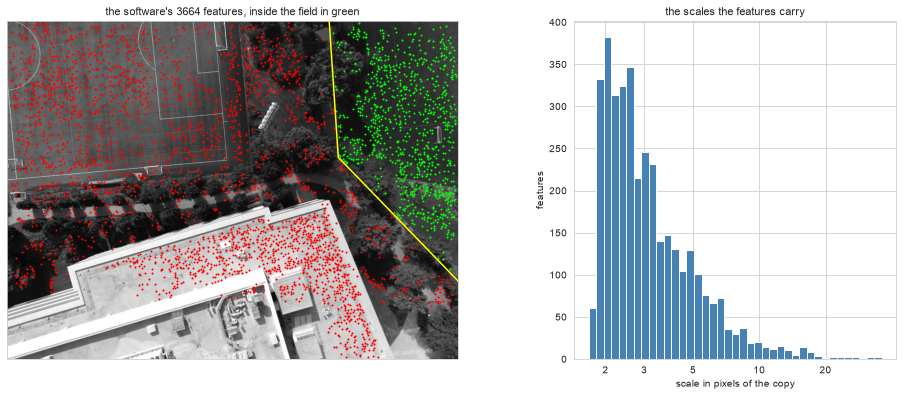

In [6]:
features = np.load("data/features_pair.npz")
points_a = features["points_a"]                                             # x, y normalised, scale, angle, one row per feature
size = max(sample_w, sample_h)
u_a = points_a[:, 0] * size + sample_w / 2 - 0.5                            # pixel = normalised times the longer side, plus the centre
v_a = points_a[:, 1] * size + sample_h / 2 - 0.5
scale_px = points_a[:, 2] * size
soft_inside = field_path.contains_points(np.column_stack([u_a, v_a]))
report = json.load(open("data/report.json"))
detected = report["stats"]["features_statistics"]["detected_features"]
f = reference["features"]
s = f["software"]
print(f"the software found {len(points_a)} features in {str(features['name_a'])}   reference {f['pair']['a']}; over the flight {detected['mean']:.0f} per photograph on average   reference {f['per_photograph']['mean']}")
print(f"it detected at {int(features['feature_process_size'])} pixels on the long side   reference {choices['feature_process_size']}; the copy in the kit is {size} pixels on the long side")
print(f"scales in pixels of the copy   p5 {np.percentile(scale_px, 5):.2f}, median {np.percentile(scale_px, 50):.2f}, p95 {np.percentile(scale_px, 95):.2f}   reference {f['scale_px_at_sample']['p5']}, {f['scale_px_at_sample']['p50']}, {f['scale_px_at_sample']['p95']}")
print(f"the angle column runs from {points_a[:, 3].min():.0f} to {points_a[:, 3].max():.0f}")
print(f"{soft_inside.sum()} inside the field and {(~soft_inside).sum()} outside, {soft_inside.sum() / megapixels_inside:.0f} and {(~soft_inside).sum() / megapixels_outside:.0f} per megapixel   reference {s['inside_field']}, {s['outside_field']}, {s['per_megapixel_inside']:.0f}, {s['per_megapixel_outside']:.0f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.6), gridspec_kw={"width_ratios": [2, 1]})
axes[0].imshow(gray, cmap="gray")
axes[0].plot(field_u, field_v, color="yellow", linewidth=1.5)
axes[0].scatter(u_a[soft_inside], v_a[soft_inside], s=4, color="lime", linewidths=0)
axes[0].scatter(u_a[~soft_inside], v_a[~soft_inside], s=4, color="red", linewidths=0)
axes[0].set_xlim(0, sample_w); axes[0].set_ylim(sample_h, 0); axes[0].set_xticks([]); axes[0].set_yticks([])
axes[0].set_title(f"the software's {len(points_a)} features, inside the field in green", fontsize=11)
axes[1].hist(scale_px, bins=np.geomspace(scale_px.min(), scale_px.max(), 40), color="steelblue")
axes[1].set_xscale("log"); axes[1].set_xlabel("scale in pixels of the copy"); axes[1].set_ylabel("features")
ticks = [t for t in (1, 2, 3, 5, 10, 20, 50, 100) if scale_px.min() <= t <= scale_px.max()]
axes[1].set_xticks(ticks); axes[1].set_xticklabels([str(t) for t in ticks]); axes[1].minorticks_off()
axes[1].set_title("the scales the features carry", fontsize=11)
fig.tight_layout()

Read the count against the flight's mean, then the line about the size at which the software detected. That size is the copy's own size, so the picture you are looking at is exactly what the software looked at, and no feature was lost to the downsizing; a feature the software found at a scale of two or three pixels here is a feature of two or three pixels in its files too. The histogram of scales is long tailed, most features a few pixels across and a few of them tens, which is the same shape as the blobs per octave above, and the angle's range spans a full turn, in degrees.

Now the two numbers per megapixel, read against the corners by hand. They need not agree, and on the pre-flight of 17 September they disagreed the other way from what the lecture would lead you to expect, since the software found more features per megapixel inside the field than outside, while the strongest thousand corners by hand avoid the field almost entirely, as the your turn shows. The honest reading is that a mown lawn has plenty of weak texture and very few strong corners, that a detector with a low threshold harvests the weak texture happily, and that neither count says anything yet about whether those features can be matched. What matters is what survives matching, and 03b-03 shows that.

## The descriptor, 128 numbers

A feature's position says where it is, and its descriptor says what it looks like, in a form that can be compared. The software's descriptor is SIFT's, with a refinement in how the patch is pooled over sizes. The patch around the feature, resampled at its scale and turned to its direction, is divided into a grid of four by four cells, and in each cell the directions of the gradient are counted into eight bins, weighted by their strength; sixteen cells times eight bins are the 128 numbers, normalised and stored as small integers. Two features of the same thing give nearly the same 128 numbers, and two features of different things do not. Here is one on the roof and one on the lawn, as bar charts, with the distance between them and the distance from each to its nearest descriptor in the pair's second photograph, found by comparing it with every one of them:

the descriptor values are integers from 0 to 148   reference 0 to 148; every descriptor has a length of about 512
the roof feature sits at pixel (1305, 871) with a scale of 3.8 px, the lawn feature at (1639, 750) with 3.1 px
distance between the two descriptors   340
the roof feature's nearest descriptor in the second photograph is 41 away and the second nearest 106, a ratio of 0.38
the lawn feature's nearest descriptor in the second photograph is 96 away and the second nearest 150, a ratio of 0.64


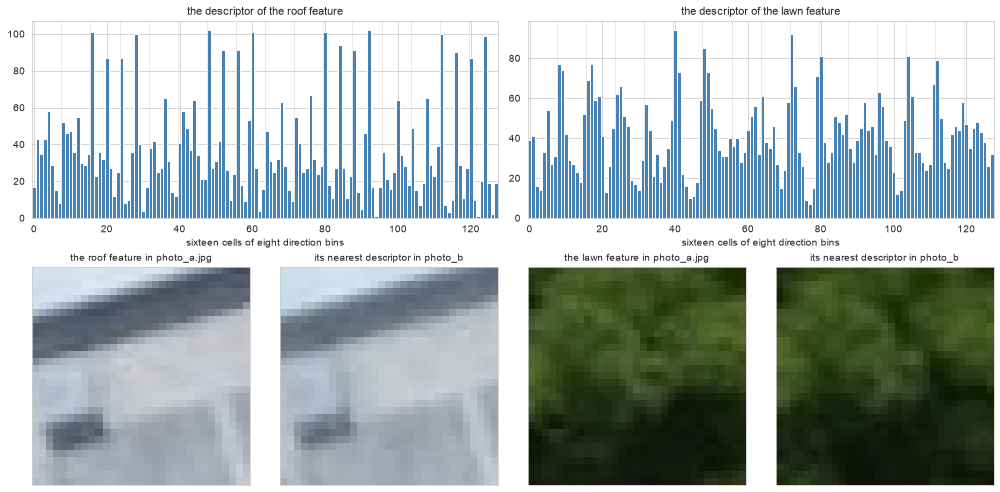

In [7]:
descriptors_a = features["descriptors_a"].astype(np.float32)
descriptors_b = features["descriptors_b"].astype(np.float32)
points_b = features["points_b"]
img_a = np.asarray(img)
img_b = np.asarray(Image.open("data/photo_b.jpg"))
b_h, b_w = img_b.shape[:2]
u_b = points_b[:, 0] * max(b_w, b_h) + b_w / 2 - 0.5
v_b = points_b[:, 1] * max(b_w, b_h) + b_h / 2 - 0.5

# one feature on the roof, inside the roof's outline shrunk by four metres and nearest its corner; one on the lawn, inside the field and nearest the window's centre
roof = largest(building.intersection(window).buffer(-4))
roof_u, roof_v = to_pixels(np.array(roof.exterior.coords))
on_roof = MplPath(np.column_stack([roof_u, roof_v])).contains_points(np.column_stack([u_a, v_a]))
roof_i = int(np.argmin(np.where(on_roof, np.hypot(u_a - corner_u, v_a - corner_v), np.inf)))
centre_u, centre_v = (float(c[0]) for c in to_pixels([choices["window"]["centre"]]))
lawn_i = int(np.argmin(np.where(soft_inside, np.hypot(u_a - centre_u, v_a - centre_v), np.inf)))

lo, hi = reference["features"]["descriptor_range"]
print(f"the descriptor values are integers from {int(descriptors_a.min())} to {int(descriptors_a.max())}   reference {lo} to {hi}; every descriptor has a length of about {np.linalg.norm(descriptors_a, axis=1).mean():.0f}")
print(f"the roof feature sits at pixel ({u_a[roof_i]:.0f}, {v_a[roof_i]:.0f}) with a scale of {scale_px[roof_i]:.1f} px, the lawn feature at ({u_a[lawn_i]:.0f}, {v_a[lawn_i]:.0f}) with {scale_px[lawn_i]:.1f} px")
print(f"distance between the two descriptors   {np.linalg.norm(descriptors_a[roof_i] - descriptors_a[lawn_i]):.0f}")
nearest = {}
for label, i in (("roof", roof_i), ("lawn", lawn_i)):
    distance = np.linalg.norm(descriptors_b - descriptors_a[i], axis=1)          # brute force, against every descriptor of photo_b
    two = np.sort(distance)[:2]
    nearest[label] = int(np.argmin(distance))
    print(f"the {label} feature's nearest descriptor in the second photograph is {two[0]:.0f} away and the second nearest {two[1]:.0f}, a ratio of {two[0] / two[1]:.2f}")

def patch(image, u, v, half=15):
    u, v = int(round(u)), int(round(v))
    return image[max(v - half, 0):v + half + 1, max(u - half, 0):u + half + 1]

fig = plt.figure(figsize=(14, 7))
grid = fig.add_gridspec(2, 4, height_ratios=[1, 1.15])
for k, (label, i) in enumerate((("roof", roof_i), ("lawn", lawn_i))):
    ax = fig.add_subplot(grid[0, 2 * k:2 * k + 2])
    ax.bar(np.arange(128), descriptors_a[i], width=1.0, color="steelblue")
    for cell in range(1, 16):
        ax.axvline(cell * 8 - 0.5, color="0.85", linewidth=0.6)
    ax.set_xlim(-0.5, 127.5); ax.set_xlabel("sixteen cells of eight direction bins"); ax.set_title(f"the descriptor of the {label} feature", fontsize=11)
panels = [(f"the roof feature in {choices['photos']['a']['kit_file']}", img_a, u_a[roof_i], v_a[roof_i]), ("its nearest descriptor in photo_b", img_b, u_b[nearest["roof"]], v_b[nearest["roof"]]),
          (f"the lawn feature in {choices['photos']['a']['kit_file']}", img_a, u_a[lawn_i], v_a[lawn_i]), ("its nearest descriptor in photo_b", img_b, u_b[nearest["lawn"]], v_b[nearest["lawn"]])]
for k, (title, image, u, v) in enumerate(panels):
    ax = fig.add_subplot(grid[1, k])
    ax.imshow(patch(image, u, v), interpolation="nearest"); ax.set_xticks([]); ax.set_yticks([]); ax.set_title(title, fontsize=10)
fig.tight_layout()

Read the bar charts first. The 128 bars are sixteen groups of eight, one group per cell of the grid over the patch, and within a group the bars are the eight directions; a patch with one strong edge fills one or two bins in every cell it crosses, a patch of texture spreads its weight over many, and the descriptor is the shape of that spread rather than any brightness or colour, which is why it survives a change of light. The values are small integers, which is how the software stores them without loss, and every descriptor has nearly the same length, because it was normalised.

Then the distances. The one between the roof feature and the lawn feature is the scale of the space, since two different things are far apart. The nearest neighbour of each in the second photograph is much nearer, and the patches below show what it found; look at whether the two patches of the roof are the same vent or the same corner, and whether the two patches of lawn are anything you could tell apart from any other patch of lawn. Then read the ratios. A nearest neighbour that is far nearer than the second nearest is a confident match, and a nearest neighbour that is only just nearer than the second is a feature that looks like several things in the other photograph, which on a roof of identical vents or a lawn of identical grass is exactly what happens. That ratio, and not the distance itself, is the test 03b-03 applies, and it applies it to every feature of the pair.

## Your turn

Repeat the count of the second section for the strongest thousand corners rather than the strongest five thousand, how many fall inside the field and how many outside, per megapixel, and say in a sentence what changed between the two counts and what that says about the lawn.

The cell below has the lines with blanks. Fill them, remove the `#` at the start of each line, and run it. There is no class answer on the board.

In [8]:
# Your attempt. harris, gray, field_path, megapixels_inside and megapixels_outside are all defined above.
#
# rows_1000, cols_1000, _ = harris(gray, n=___)
# inside_1000 = field_path.contains_points(np.column_stack([___, ___]))          # columns first, then rows, as the path expects x then y
# print(f"of the strongest {len(rows_1000)} corners {inside_1000.sum()} are inside the field and {(~inside_1000).sum()} outside")
# print(f"per megapixel that is {inside_1000.sum() / ___:.0f} inside and {(~inside_1000).sum() / ___:.0f} outside")

## Check your understanding

1. The Harris response is large where both eigenvalues of the structure tensor are large. Say in words what the picture looks like at a point where both are small, where one is large, and where both are large, and which of the three a matcher can use.
2. A difference-of-Gaussians extremum is found in a stack over scale as well as over position. Explain why that gives the feature a size, and what would go wrong in matching two flights at different altitudes if features carried no size.
3. The descriptor is measured in the feature's own frame, at its scale and turned to its direction, from gradient directions rather than brightness. Name three changes between two photographs of the same roof that it is therefore invariant to, and one that it is not.
4. The software detected its features at 2000 pixels on the long side rather than at the full frame. Say why that is not a loss for the matching, and what it would cost if the features were later used to measure something at the full frame's precision.

## Where we are

You can find corners in a photograph with a few lines of scipy and say why they sit where they do, you have projected the field's outline into a photograph and counted what falls inside it against the rest, and you have seen why a feature must carry a scale and a direction before it can be found again from another height or heading. You have opened the software's features of the same photograph, converted their normalised coordinates to pixels, read their count against the flight's and their scales as a histogram, and taken one descriptor apart into its sixteen cells of eight directions. You know that distance in descriptor space is what matching compares, and that the ratio of the nearest to the second nearest, not the distance, is what decides.

The habit worth keeping: before you ask why a model is bad somewhere, look at what the detector found there, because a surface with no features worth matching cannot be reconstructed no matter what the rest of the pipeline does.

In 03b-03 we match these features between two photographs and join the matches into tracks.

## Further resources

Nothing in this course requires anything below.

The corner detector is Harris and Stephens, A combined corner and edge detector, Proceedings of the Alvey Vision Conference, 1988. The scale, the orientation and the descriptor are Lowe's, Distinctive image features from scale-invariant keypoints, International Journal of Computer Vision, 2004, free from the author: https://www.cs.ubc.ca/~lowe/papers/ijcv04.pdf. The refinement the software uses is DSP-SIFT, Dong and Soatto, Domain-size pooling in local descriptors, CVPR 2015: https://openaccess.thecvf.com/content_cvpr_2015/papers/Dong_Domain-Size_Pooling_in_2015_CVPR_paper.pdf

Szeliski's Computer Vision, free online, covers feature detection, description and matching in chapter 7: https://szeliski.org/Book/. OpenSfM's documentation describes its feature types, the normalised image coordinates and the feature files the kit carries: https://opensfm.org/docs/

The photographs, the features and the report are the course's own flight, published under CC BY 4.0. The outline of Poe Field is an OpenStreetMap extract, licensed ODbL 1.0, copyright OpenStreetMap contributors: https://www.openstreetmap.org/copyright. The building outlines come from the same extract, under the same licence.

## Appendix, in case you are stuck

Try properly first. If you do use these, treat them the way you would treat an agent's answer. Read them, run them, and say why yours differed.

The strongest thousand corners inside and outside the field per megapixel, recomputed from the files so that the cell stands on its own; the projection is the one of the notebook's second cell, shortened:

```python
import json
import math
import numpy as np
import geopandas as gpd
import rasterio
from PIL import Image
from scipy import ndimage as ndi
from shapely.geometry import Polygon, box
from matplotlib.path import Path as MplPath

flight = json.load(open("data/flight.json")); choices = flight["p03b"]
gray = np.asarray(Image.open("data/photo_a.jpg").convert("L"), dtype=np.float32)
sample_h, sample_w = gray.shape
ix = ndi.gaussian_filter(gray, 1.0, order=(0, 1)); iy = ndi.gaussian_filter(gray, 1.0, order=(1, 0))
sxx, syy, sxy = (ndi.gaussian_filter(p, 2.0) for p in (ix * ix, iy * iy, ix * iy))
response = (sxx * syy - sxy * sxy) - 0.05 * (sxx + syy) ** 2
peaks = (response == ndi.maximum_filter(response, size=7)) & (response > 0)
rows, cols = np.nonzero(peaks)
order = np.argsort(-response[rows, cols])[:1000]
rows, cols = rows[order], cols[order]

block = np.load("data/block.npz"); camera = json.loads(str(block["camera"]))
shot = [str(n) for n in block["names"]].index(choices["photos"]["a"]["name"])
rv = np.asarray(block["rotation_map"][shot], dtype=float); theta = float(np.linalg.norm(rv)); k = rv / theta
K = np.array([[0.0, -k[2], k[1]], [k[2], 0.0, -k[0]], [-k[1], k[0], 0.0]])
R = np.eye(3) + math.sin(theta) * K + (1.0 - math.cos(theta)) * K @ K
with rasterio.open("data/dtm_window.tif") as src:
    z_ground = float(np.nanmedian(src.read(1, masked=True).filled(np.nan)))
field = gpd.read_file("data/site.gpkg", layer="site").to_crs(choices["crs"]).geometry.iloc[0]
ring = np.array(field.exterior.coords)
X = np.column_stack([ring[:, 0] - block["offset"][0], ring[:, 1] - block["offset"][1], np.full(len(ring), z_ground)])
p = X @ R.T + block["translation_map"][shot]
x, y = p[:, 0] / p[:, 2], p[:, 1] / p[:, 2]
r2 = x * x + y * y; radial = 1 + camera["k1"] * r2 + camera["k2"] * r2 ** 2 + camera["k3"] * r2 ** 3
xd = x * radial + 2 * camera["p1"] * x * y + camera["p2"] * (r2 + 2 * x * x)
yd = y * radial + 2 * camera["p2"] * x * y + camera["p1"] * (r2 + 2 * y * y)
size = max(sample_w, sample_h)
u = (camera["focal_x"] * xd + camera["c_x"]) * size + sample_w / 2 - 0.5
v = (camera["focal_y"] * yd + camera["c_y"]) * size + sample_h / 2 - 0.5
share = Polygon(np.column_stack([u, v])).intersection(box(0, 0, sample_w, sample_h)).area / (sample_w * sample_h)
inside = MplPath(np.column_stack([u, v])).contains_points(np.column_stack([cols, rows]))
print(f"of the strongest {len(rows)} corners {inside.sum()} are inside the field and {(~inside).sum()} outside")
print(f"per megapixel that is {inside.sum() / (share * sample_w * sample_h / 1e6):.0f} inside and {(~inside).sum() / ((1 - share) * sample_w * sample_h / 1e6):.0f} outside")
```

Compare the two densities with the ones the notebook printed for the strongest five thousand. The strongest corners of a photograph of this site are the roof's edges, the vents, the painted lines and the kerbs, and almost none of them are on the lawn; what the lawn has is weak texture, which a low threshold harvests and a high one does not. Which of the two the matcher can use is a question about the next photograph rather than this one, and 03b-03 answers it with a count of the matches that survive.